***Link data (Cifar 10)***
- https://www.kaggle.com/datasets/ayush1220/cifar10

# Case Study 7 – Phân cụm ảnh dựa trên feature từ CNN

**Mục tiêu:**
- Sử dụng dataset CIFAR-10 (10 lớp ảnh màu kích thước 32x32).
- Dùng mạng CNN pretrained (transfer learning) để **trích xuất đặc trưng (feature vector)** cho từng ảnh.
- Dùng thuật toán **K-Means** để phân cụm ảnh trong không gian feature.
- Đánh giá & trực quan:
  - Phân bố số lượng ảnh theo từng lớp (label thật).
  - Trực quan một số ảnh mẫu.
  - Dùng **confusion matrix** để so sánh **cluster vs nhãn thật** (dùng nhãn chỉ cho mục đích đánh giá).
  - Vẽ **inertia theo số cụm (elbow)**, và **đánh giá cluster accuracy**.

**Lưu ý:**
- Đây là **bài toán phân cụm (unsupervised)**:
  - K-Means **không sử dụng nhãn thật để training**, chỉ dùng ảnh (feature).
  - Nhãn thật chỉ dùng để **đánh giá** chất lượng phân cụm.
- Framework sử dụng:
  - **TensorFlow / Keras** cho CNN pretrained.
  - **scikit-learn** cho KMeans, confusion matrix, các metric.
  - **KHÔNG sử dụng PyTorch.**


In [2]:
#B22DCCN476 - Đỗ Ngọc Lâm
#Cell [2]. [Import thư viện & đặt seed]

import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.metrics import silhouette_score

import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras import Model

# Đặt seed để kết quả reproducible
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.20.0


## 1. Load dataset CIFAR-10

- CIFAR-10 gồm:
  - 50.000 ảnh train
  - 10.000 ảnh test
  - 10 lớp (0–9)
- Để trích feature bằng CNN pretrained (ResNet50), thời gian xử lý sẽ khá lâu nếu dùng toàn bộ.
- Trong case study này:
  - Ta dùng **10.000 ảnh đầu tiên** từ train set (có thể tăng/giảm tùy tài nguyên máy).
  - Mỗi ảnh được resize lên 224x224 rồi đưa qua ResNet50 (không gồm fully-connected head).

Ta cũng:
- Lưu lại `class_names` để hiển thị nhãn dễ hiểu.
- Visualize phân bố label trước khi phân cụm.


In [4]:
#B22DCCN476 - Đỗ Ngọc Lâm
#Cell [4]. [Load CIFAR-10 & chọn subset]

from tensorflow.keras.datasets import cifar10

# Load CIFAR-10
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# y_* shape: (N, 1) -> flatten thành (N,)
y_train = y_train.flatten()
y_test = y_test.flatten()

print("Train shape:", x_train.shape, "Labels:", y_train.shape)
print("Test shape :", x_test.shape,  "Labels:", y_test.shape)

# Danh sách tên lớp CIFAR-10
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# Chọn subset để phân cụm (ví dụ: 10.000 ảnh đầu tiên)
N_SAMPLES = 10000
x_data = x_train[:N_SAMPLES]
y_data = y_train[:N_SAMPLES]

print("Subset dùng cho phân cụm:", x_data.shape, y_data.shape)


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 49s 0us/step
Train shape: (50000, 32, 32, 3) Labels: (50000,)
Test shape : (10000, 32, 32, 3) Labels: (10000,)
Subset dùng cho phân cụm: (10000, 32, 32, 3) (10000,)


## 2. Trực quan hóa phân bố dữ liệu

Trước khi trích feature và phân cụm, ta cần:
- Xem **phân bố số lượng ảnh theo từng lớp** (label thật).
- Visualize **một vài ảnh mẫu** để mô tả dataset trong báo cáo.

Việc này giúp:
- Hiểu dataset có cân bằng giữa các lớp hay không.
- Minh họa trực quan cho phần mô tả dữ liệu.


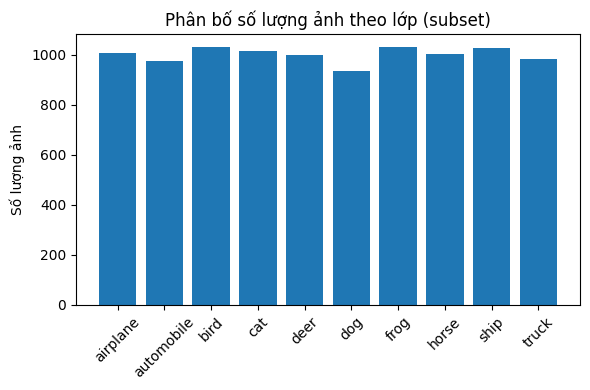

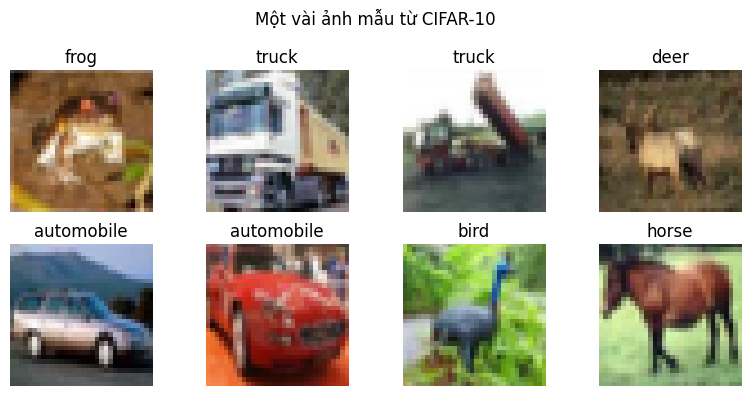

In [5]:
#B22DCCN476 - Đỗ Ngọc Lâm
#Cell [6]. [Vẽ phân bố nhãn & một vài ảnh mẫu]

# Đếm số lượng theo nhãn
unique, counts = np.unique(y_data, return_counts=True)

plt.figure(figsize=(6, 4))
plt.bar([class_names[i] for i in unique], counts)
plt.xticks(rotation=45)
plt.title("Phân bố số lượng ảnh theo lớp (subset)")
plt.ylabel("Số lượng ảnh")
plt.tight_layout()
plt.show()

# Hiển thị một vài ảnh mẫu
plt.figure(figsize=(8, 4))
for i in range(8):
    plt.subplot(2, 4, i+1)
    plt.imshow(x_data[i])
    plt.title(class_names[y_data[i]])
    plt.axis('off')
plt.suptitle("Một vài ảnh mẫu từ CIFAR-10")
plt.tight_layout()
plt.show()


## 3. Xây CNN pretrained để trích xuất đặc trưng

Ta sử dụng **ResNet50** pretrained trên ImageNet, với các thiết lập:

- `include_top=False`: bỏ phần fully-connected classification head.
- `weights='imagenet'`: sử dụng trọng số đã pretrain.
- `pooling='avg'`: áp dụng **Global Average Pooling** sau cùng → mỗi ảnh → 1 vector feature cố định.

Pipeline trích đặc trưng:

1. Resize ảnh CIFAR-10 (32x32) lên kích thước chuẩn ResNet50: **224x224x3**.
2. Áp dụng `preprocess_input` (chuẩn hóa theo chuẩn ImageNet).
3. Đưa qua ResNet50 → thu được **feature vector** cho mỗi ảnh.
4. Lưu feature thành một mảng `X_features` (shape: `[N_SAMPLES, feature_dim]`).


In [6]:
#B22DCCN476 - Đỗ Ngọc Lâm
#Cell [8]. [Khởi tạo ResNet50 pretrained & chuẩn bị hàm trích feature]

IMG_SIZE = 224

# ResNet50 pretrained (ImageNet)
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    pooling='avg',      # Global Average Pooling -> vector 2048-dim
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

# Đóng băng trọng số (chỉ dùng để feature extraction, không fine-tune)
base_model.trainable = False

# Xây model trích feature
feature_extractor = Model(inputs=base_model.input, outputs=base_model.output)

print("Feature extractor output shape (1 ảnh):", feature_extractor.output_shape)


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 10s 0us/step
Feature extractor output shape (1 ảnh): (None, 2048)


## 4. Trích xuất đặc trưng cho toàn bộ ảnh

Do ResNet50 khá nặng, ta nên:
- Dùng **batch processing** (ví dụ `batch_size = 64`).
- Mỗi batch:
  - Resize ảnh về 224x224.
  - Gọi `preprocess_input` để chuẩn hóa.
  - Gọi `feature_extractor.predict()` để lấy vector đặc trưng.

Kết quả:
- Mảng `X_features` có kích thước `[N_SAMPLES, feature_dim]`.
- Đây chính là input cho thuật toán **K-Means**.


In [7]:
#B22DCCN476 - Đỗ Ngọc Lâm
#Cell [10]. [Trích xuất feature từ CNN cho toàn bộ ảnh]

def extract_features_from_images(images, batch_size=64):
    """
    images: numpy array shape (N, H, W, 3) - CIFAR-10 32x32x3
    Return: features array shape (N, feature_dim)
    """
    n_samples = images.shape[0]
    features_list = []

    for start in range(0, n_samples, batch_size):
        end = min(start + batch_size, n_samples)
        batch = images[start:end].astype('float32')

        # Resize lên 224x224
        batch_resized = tf.image.resize(batch, (IMG_SIZE, IMG_SIZE))

        # Chuẩn hóa theo chuẩn ResNet
        batch_preprocessed = preprocess_input(batch_resized)

        # Trích feature
        batch_features = feature_extractor.predict(batch_preprocessed, verbose=0)
        features_list.append(batch_features)

    features = np.vstack(features_list)
    return features

X_features = extract_features_from_images(x_data, batch_size=64)
print("X_features shape:", X_features.shape)


X_features shape: (10000, 2048)


## 5. Phân cụm bằng K-Means trên feature CNN

Vì CIFAR-10 có 10 lớp nên:
- Ta đặt **số cụm K = 10** cho mô hình chính.
- Trước đó, ta có thể:
  - Tính **inertia** với nhiều giá trị K (ví dụ 2 → 12) để minh họa **elbow method**.
  - Tính **silhouette score** cho từng K để đánh giá chất lượng phân cụm.

Đây là cách thay thế hợp lý cho việc vẽ `loss/valLoss` trong bài toán phân cụm (unsupervised).


K= 2 -> inertia=9.07e+06, silhouette=0.0690
K= 3 -> inertia=8.82e+06, silhouette=0.0458
K= 4 -> inertia=8.49e+06, silhouette=0.0537
K= 5 -> inertia=8.30e+06, silhouette=0.0552
K= 6 -> inertia=8.18e+06, silhouette=0.0517
K= 7 -> inertia=8.11e+06, silhouette=0.0398
K= 8 -> inertia=8.03e+06, silhouette=0.0406
K= 9 -> inertia=7.94e+06, silhouette=0.0384
K=10 -> inertia=7.86e+06, silhouette=0.0403
K=11 -> inertia=7.82e+06, silhouette=0.0367
K=12 -> inertia=7.77e+06, silhouette=0.0375


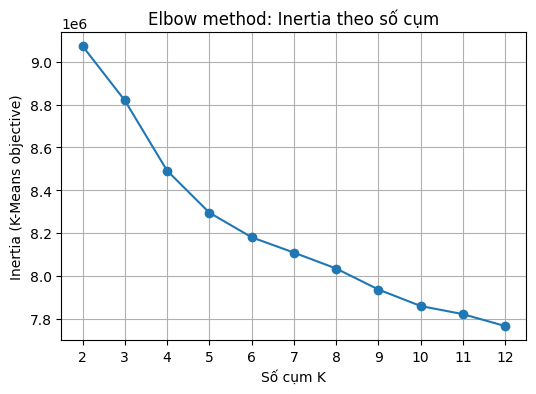

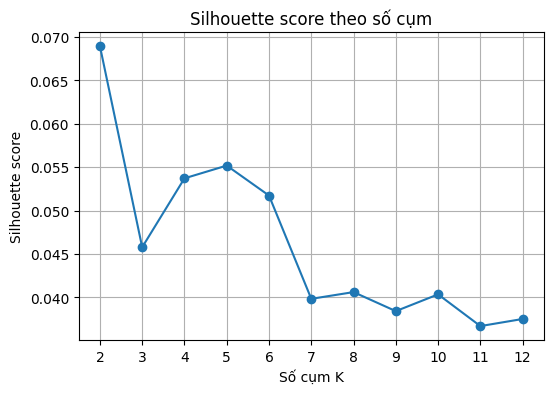

In [8]:
#B22DCCN476 - Đỗ Ngọc Lâm
#Cell [12]. [Tính inertia & silhouette cho nhiều giá trị K]

k_values = range(2, 13)
inertias = []
sil_scores = []

for k in k_values:
    kmeans_tmp = KMeans(n_clusters=k, random_state=SEED, n_init='auto')
    kmeans_tmp.fit(X_features)
    inertias.append(kmeans_tmp.inertia_)
    
    # Silhouette score tính được nếu số mẫu > số cụm
    labels_tmp = kmeans_tmp.labels_
    sil = silhouette_score(X_features, labels_tmp)
    sil_scores.append(sil)
    print(f"K={k:2d} -> inertia={kmeans_tmp.inertia_:.2e}, silhouette={sil:.4f}")

# Vẽ inertia (elbow)
plt.figure(figsize=(6, 4))
plt.plot(k_values, inertias, marker='o')
plt.xlabel("Số cụm K")
plt.ylabel("Inertia (K-Means objective)")
plt.title("Elbow method: Inertia theo số cụm")
plt.xticks(k_values)
plt.grid(True)
plt.show()

# Vẽ silhouette
plt.figure(figsize=(6, 4))
plt.plot(k_values, sil_scores, marker='o')
plt.xlabel("Số cụm K")
plt.ylabel("Silhouette score")
plt.title("Silhouette score theo số cụm")
plt.xticks(k_values)
plt.grid(True)
plt.show()


## 6. Huấn luyện mô hình K-Means với K = 10

- Ta chọn **K = 10** (tương ứng 10 lớp CIFAR-10).
- Sau khi K-Means hội tụ, ta có:
  - `cluster_labels`: nhãn cụm (0–9) cho từng ảnh.
- Để đánh giá, ta:
  - Dùng **nhãn thật `y_data`**.
  - Map mỗi **cluster → lớp chiếm đa số** trong cluster đó.
  - Từ đó suy ra **predicted class** cho từng ảnh, rồi vẽ confusion matrix.


In [9]:
#B22DCCN476 - Đỗ Ngọc Lâm
#Cell [14]. [Huấn luyện KMeans K=10 & map cluster -> class]

K = 10
kmeans = KMeans(n_clusters=K, random_state=SEED, n_init='auto')
kmeans.fit(X_features)

cluster_labels = kmeans.labels_
print("Cluster labels shape:", cluster_labels.shape)

# Map mỗi cluster -> class name chiếm đa số trong cluster đó
cluster_to_class = {}

for c in range(K):
    idx = np.where(cluster_labels == c)[0]
    if len(idx) == 0:
        continue
    true_labels_in_cluster = y_data[idx]
    # Lớp phổ biến nhất (mode)
    values, counts = np.unique(true_labels_in_cluster, return_counts=True)
    majority_class = values[np.argmax(counts)]
    cluster_to_class[c] = majority_class

print("Mapping cluster -> majority class (theo nhãn thật):")
for c, cls in cluster_to_class.items():
    print(f"  Cluster {c} -> Class {cls} ({class_names[cls]})")

# Suy ra "predicted class" từ cluster label
y_pred_class = np.array([cluster_to_class[c] for c in cluster_labels])


Cluster labels shape: (10000,)
Mapping cluster -> majority class (theo nhãn thật):
  Cluster 0 -> Class 8 (ship)
  Cluster 1 -> Class 9 (truck)
  Cluster 2 -> Class 6 (frog)
  Cluster 3 -> Class 0 (airplane)
  Cluster 4 -> Class 3 (cat)
  Cluster 5 -> Class 1 (automobile)
  Cluster 6 -> Class 4 (deer)
  Cluster 7 -> Class 5 (dog)
  Cluster 8 -> Class 7 (horse)
  Cluster 9 -> Class 2 (bird)


## 7. Đánh giá phân cụm bằng Confusion Matrix

Sau khi map cluster → class, ta có thể:
- So sánh `y_pred_class` với `y_data` như một mô hình phân loại.
- Tính:
  - **Confusion matrix** (10x10).
  - **Classification report**: precision, recall, F1-score cho từng lớp.
  - **Overall accuracy** (coi như "cluster accuracy").

Lưu ý:  
Đây KHÔNG phải là mô hình supervised thực sự – ta chỉ dùng nhãn thật để **đánh giá** chất lượng phân cụm.


<Figure size 800x600 with 0 Axes>

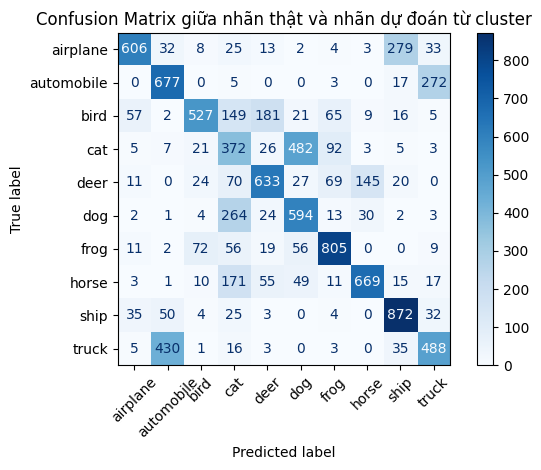

Classification report (cluster-based classification):
              precision    recall  f1-score   support

    airplane       0.82      0.60      0.70      1005
  automobile       0.56      0.70      0.62       974
        bird       0.79      0.51      0.62      1032
         cat       0.32      0.37      0.34      1016
        deer       0.66      0.63      0.65       999
         dog       0.48      0.63      0.55       937
        frog       0.75      0.78      0.77      1030
       horse       0.78      0.67      0.72      1001
        ship       0.69      0.85      0.76      1025
       truck       0.57      0.50      0.53       981

    accuracy                           0.62     10000
   macro avg       0.64      0.62      0.63     10000
weighted avg       0.64      0.62      0.63     10000

Overall 'cluster accuracy': 0.6243


In [10]:
#B22DCCN476 - Đỗ Ngọc Lâm
#Cell [16]. [Confusion matrix & classification report]

cm = confusion_matrix(y_data, y_pred_class)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

plt.figure(figsize=(8, 6))
disp.plot(xticks_rotation=45, cmap='Blues', values_format='d')
plt.title("Confusion Matrix giữa nhãn thật và nhãn dự đoán từ cluster")
plt.tight_layout()
plt.show()

print("Classification report (cluster-based classification):")
print(classification_report(y_data, y_pred_class, target_names=class_names))

accuracy = (y_data == y_pred_class).mean()
print(f"Overall 'cluster accuracy': {accuracy:.4f}")


## 8. Tóm tắt pipeline trích xuất đặc trưng & phân cụm

Pipeline tổng thể của Case Study 7:

1. **Chuẩn bị dữ liệu**
   - Sử dụng dataset CIFAR-10 (10 lớp, ảnh màu 32x32).
   - Chọn một subset gồm 10.000 ảnh để giảm thời gian xử lý.
   - Trực quan hóa:
     - Phân bố số lượng ảnh theo từng lớp.
     - Một số ảnh mẫu đại diện cho dataset.

2. **Trích xuất đặc trưng bằng CNN pretrained**
   - Sử dụng mô hình **ResNet50** pretrained trên ImageNet, với:
     - `include_top=False` để bỏ phần fully-connected classification head.
     - `pooling='avg'` để thực hiện **Global Average Pooling**, thu được 1 vector đặc trưng cho mỗi ảnh.
   - Các bước xử lý ảnh:
     - Resize ảnh CIFAR-10 từ 32x32 lên 224x224 để phù hợp với input của ResNet50.
     - Chuẩn hóa ảnh bằng hàm `preprocess_input` (chuẩn ImageNet).
     - Cho ảnh qua ResNet50 để thu được vector đặc trưng có kích thước cố định.
   - Kết quả:
     - Mỗi ảnh được biểu diễn bởi 1 vector feature trong không gian nhiều chiều (embedding space).

3. **Phân cụm bằng K-Means**
   - Áp dụng K-Means lên tập vector đặc trưng với số cụm **K = 10**.
   - Trước đó, dùng **elbow method** (inertia) và **silhouette score** để phân tích chất lượng phân cụm cho nhiều giá trị K khác nhau.

4. **Đánh giá chất lượng phân cụm**
   - Nhãn thật (CIFAR-10 labels) **không dùng để huấn luyện**, chỉ dùng để đánh giá:
     - Với mỗi cluster, tìm ra lớp chiếm đa số → map cluster → majority class.
     - Suy ra “nhãn dự đoán” cho mỗi ảnh từ nhãn cluster.
     - Vẽ **confusion matrix** giữa nhãn thật và nhãn dự đoán.
     - Tính các chỉ số: precision, recall, F1-score cho từng lớp, cùng với overall cluster accuracy.
   - Đây là cách thực tế để lượng hóa chất lượng phân cụm trong bối cảnh có sẵn nhãn nhưng không dùng để training.

Pipeline này minh họa rõ ràng cách:
- Kết hợp **Transfer Learning (ResNet50)** để trích xuất feature mạnh mẽ cho ảnh.
- Áp dụng **thuật toán phân cụm K-Means** trong không gian feature để nhóm ảnh có nội dung tương tự nhau.


### Đánh giá chất lượng phân cụm

Kết quả thực nghiệm cho thấy cluster accuracy đạt **62.43%** trên tập dữ liệu CIFAR-10. Đây là mức kết quả phù hợp với bài toán phân cụm **unsupervised**, trong đó mô hình không sử dụng nhãn thật trong quá trình huấn luyện mà chỉ khai thác thông tin hình thái và thị giác từ đặc trưng CNN.

Giá trị accuracy chưa đạt mức cao như các mô hình phân loại có giám sát, do một số nguyên nhân:

- Nhiều lớp trong CIFAR-10 có đặc trưng hình ảnh tương đối tương đồng (ví dụ: *cat – dog – deer*, *automobile – truck*), khiến không gian embedding bị chồng lấn.
- Mô hình ResNet50 được pretrained trên ImageNet và không được fine-tune cho dữ liệu CIFAR-10, nên đặc trưng chưa tối ưu hoàn toàn cho các ảnh kích thước nhỏ.
- Thuật toán K-Means chỉ mô hình hóa cluster dạng cầu và phụ thuộc vào khoảng cách Euclidean, trong khi phân bố dữ liệu trong không gian đặc trưng CNN thường có cấu trúc phi tuyến phức tạp.

Mặc dù còn hạn chế, kết quả **62.43%** cho thấy pipeline đề xuất đã khai thác hiệu quả các biểu diễn CNN để phân nhóm ảnh cùng lớp tương đối tốt, vượt trội so với các phương pháp clustering dựa trên pixel thô.
